# Import a GDS-II layout into COMSOL

This notebook launches COMSOL through the Python `mph` bridge, imports the GDS electrodes as 0.5 µm metal domains, constructs the SiO₂/Si chip and surrounding air, solves electrostatics, and extracts RF-to-ground capacitance.

## Requirements and modeling choice

- COMSOL Multiphysics 6.1 (the code also uses APIs retained in newer versions).
- A license for the **ECAD Import Module**. GDS-II is an ECAD format; the ordinary CAD import alone is not sufficient.
- Python packages `mph`, `jpype1`, and `numpy`.

GDS-II stores planar mask polygons and hierarchy but does **not** contain a physical layer stackup. `LAYER8` is assigned an explicit 0.5 µm thickness and `LAYER0` is excluded. The dielectric stack is constructed separately from explicit dimensions.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import mph
from jpype import JArray
from jpype.types import JBoolean, JInt

# If this import fails, install into this Jupyter kernel with:
# %pip install MPh

client = mph.start(version='6.1')
print('COMSOL version:', client.version)
model = client.create('gds_import')
j = model.java


COMSOL version: 6.1


## 1. Select and validate the GDS file

Replace the example path below. A raw string (`r'...'`) is used so Windows backslashes are not interpreted as escape characters. The `.gds` extension is required for COMSOL to identify the file as GDS-II.

In [2]:
GDS_FILE = Path(r'C:\\Users\\Administrator\\Downloads\\COMSOL_MODEL_V3.gds')

# This file has two unreferenced root cells. The device polygons are in
# 'Unnamed_12'; '$$$CONTEXT_INFO$$$' is tool-generated metadata.
# Set this to '' for a conventional GDS containing one unambiguous top cell.
GDS_CELL = 'UNNAMED_12'
ELECTRODE_LAYER = 'LAYER8'
ELECTRODE_THICKNESS_UM = 0.5
METAL_Z_MIN_UM = -ELECTRODE_THICKNESS_UM / 2
METAL_Z_MAX_UM = +ELECTRODE_THICKNESS_UM / 2

# Chip stack, all in micrometers. Metal is centered on z=0.
CHIP_LENGTH_UM = 11976.0
CHIP_WIDTH_UM = 5846.51
OXIDE_THICKNESS_UM = 12.0
SILICON_THICKNESS_UM = 675.0
AIR_Z_MIN_UM = -1000.0
AIR_Z_MAX_UM = 500.0
AIR_XY_PADDING_UM = 500.0

# Confirmed from the finalized geometry: domain 14 is RF and every other
# metal domain from 4 through 26 is GND (including DC domain 26).
RF_METAL_DOMAIN_IDS = [14]
GND_METAL_DOMAIN_IDS = [domain_id for domain_id in range(4, 27)
                        if domain_id != 14]

# Local mesh controls, all lengths in micrometers. These are practical
# baseline values for this 12 mm x 5.8 mm chip. A 2 um maximum size over
# every electrode/oxide surface creates tens of millions of elements.
MESH_RF = {'hmax': 10.0, 'hmin': 0.5, 'growth': 1.40}
MESH_GND = {'hmax': 40.0, 'hmin': 0.5, 'growth': 1.50}
MESH_SIO2 = {'hmax': 25.0, 'hmin': 1.0, 'growth': 1.40}
MESH_SILICON = {'hmax': 150.0, 'hmin': 15.0, 'growth': 1.50}
MESH_AIR = {'hmax': 500.0, 'hmin': 25.0, 'growth': 1.60}

# Resolve only after checking existence, so the error message remains useful.
if not GDS_FILE.is_file():
    raise FileNotFoundError(
        f'GDS file not found: {GDS_FILE}\n'
        'Edit GDS_FILE so it points to an existing .gds file.'
    )
if GDS_FILE.suffix.lower() != '.gds':
    raise ValueError('COMSOL ECAD import requires the filename extension .gds')

GDS_FILE = GDS_FILE.resolve()
print('Input file:', GDS_FILE)
print(f'File size : {GDS_FILE.stat().st_size / 1024:.1f} KiB')


Input file: C:\Users\Administrator\Downloads\COMSOL_MODEL_V3.gds
File size : 6.5 KiB


## 2. Create and configure the COMSOL ECAD import

`LAYER8` is imported with **Full 3D**, a thickness of 0.5 µm, and manual elevation $z=-0.25$ µm, so the metal spans $-0.25<z<+0.25$ µm. This permits robust conductor-domain selection.

In [3]:
j.component().create('comp1', JBoolean(True))
comp = j.component('comp1')
comp.geom().create('geom1', 3)
geom = comp.geom('geom1')

geom.create('imp1', 'Import')
imp = geom.feature('imp1')
imp.set('filename', str(GDS_FILE))
imp.set('updategeomunit', JBoolean(True))
imp.set('grouping', 'layer')
imp.set('importtype', 'full3d')
imp.set('manualelevation', 'on')
imp.set('intbnd', 'off')
imp.set('findarcs', 'auto')
imp.set('repairgeom', 'on')
imp.set('repairtoltype', 'auto')
imp.set('selresult', 'on')
imp.set('selresultshow', 'all')
imp.set('sellayer', 'on')
imp.set('sellayershow', 'all')

# Setting filename loads the GDS metadata before geometry construction.
ecad_type = imp.getString('ecadtype')
if str(ecad_type).lower() != 'gds':
    raise RuntimeError(f'COMSOL identified the file as {ecad_type!r}, not GDS.')

layer_table = np.asarray(imp.getStringMatrix('layerprop'), dtype=object)
if layer_table.size == 0:
    raise RuntimeError('COMSOL found no GDS layers in the file.')
if GDS_CELL:
    imp.set('cell', GDS_CELL)

# layerprop column 0 is COMSOL's layer name. Enable only LAYER8.
layer_names = [str(row[0]).upper() for row in layer_table]
import_flags = [
    'on' if name == ELECTRODE_LAYER else 'off' for name in layer_names
]
if not any(flag == 'on' for flag in import_flags):
    raise RuntimeError(
        f'Electrode layer {ELECTRODE_LAYER!r} was not found; '
        f'COMSOL reported {layer_names}.'
    )
imp.set('importlayer', import_flags)
heights = [f'{ELECTRODE_THICKNESS_UM}[um]' if flag == 'on' else '0[um]'
           for flag in import_flags]
imp.set('height', heights)
elevations = [f'{METAL_Z_MIN_UM}[um]' if flag == 'on' else '0[um]'
              for flag in import_flags]
imp.set('elevation', elevations)
print('Layer import configuration:')
for name, flag, height, elevation in zip(
        layer_names, import_flags, heights, elevations):
    print(f'  {name}: import={flag}, thickness={height}, elevation={elevation}')

# Re-read the source file and populate its ECAD metadata.
try:
    imp.importData()
except Exception as exc:
    raise RuntimeError(
        'COMSOL could not read the GDS file. Confirm that the file is valid '
        'and that an ECAD Import Module license is available.'
    ) from exc

print('Detected ECAD type:', ecad_type)
print('Imported cell:', GDS_CELL or '<automatic top cell>')


Layer import configuration:
  LAYER0: import=off, thickness=0[um], elevation=0[um]
  LAYER8: import=on, thickness=0.5[um], elevation=-0.25[um]
Detected ECAD type: gds
Imported cell: UNNAMED_12


## 3. Inspect the GDS layer table before building

COMSOL exposes the importer layer table through `layerprop`. Its exact column set can vary with COMSOL version and import mode, so this cell prints the raw table without assuming column positions. Use it to verify that the expected GDS layer/datatype pairs are present.

In [4]:
layer_table = np.asarray(imp.getStringMatrix('layerprop'), dtype=object)
print('Raw COMSOL layer table shape:', layer_table.shape)
if layer_table.size == 0:
    raise RuntimeError('The GDS file contains no layers that COMSOL can import.')

for row_number, row in enumerate(layer_table, start=1):
    print(f'{row_number:3d}:', ' | '.join(map(str, row)))


Raw COMSOL layer table shape: (2, 2)
  1: LAYER0 | Metal
  2: LAYER8 | Metal


## 4. Build the finite-thickness electrodes and measure their footprint

The imported geometry is built first so its bounding box can be measured. COMSOL returns the bounding box in geometry units—in this model, micrometers—in the order $[x_{min},x_{max},y_{min},y_{max},z_{min},z_{max}]$.

In [5]:
try:
    geom.run('imp1')
except Exception as exc:
    raise RuntimeError(
        'COMSOL read the GDS metadata but could not build the metal domains.'
    ) from exc

object_names = list(imp.objectNames())
if not object_names:
    raise RuntimeError('Import completed without producing electrode geometry.')
measure = geom.measure()
measure.selection().set(object_names)
electrode_bbox = np.asarray(measure.getBoundingBox(), dtype=float)
if electrode_bbox.size != 6:
    raise RuntimeError(f'Unexpected 3-D bounding box: {electrode_bbox}')
exmin, exmax, eymin, eymax, ezmin, ezmax = electrode_bbox
print('Geometry unit:', geom.lengthUnit())
print('Imported objects:', object_names)
print('Electrode bounding box [um]:', electrode_bbox)
print(f'Electrode span: {exmax-exmin:.6g} x {eymax-eymin:.6g} um')
assert np.allclose([ezmin, ezmax], [METAL_Z_MIN_UM, METAL_Z_MAX_UM]), (
    f'Expected metal z range [{METAL_Z_MIN_UM}, {METAL_Z_MAX_UM}] um; '
    f'got [{ezmin}, {ezmax}] um.'
)


Geometry unit: µm
Imported objects: ['imp1']
Electrode bounding box [um]: [ 5.27600000e+03  1.62760000e+04 -2.63892000e+03  3.20857007e+03
 -2.50000000e-01  2.50000000e-01]
Electrode span: 11000 x 5847.49 um


## 5. Add SiO₂, silicon, and the surrounding air domain

The substrate right edge is aligned to the electrode-layout right edge and centered in $y$. The oxide begins at the metal bottom face: $-12.25<z<-0.25$ µm. Silicon occupies $-687.25<z<-12.25$ µm. This avoids overlapping the centered metal. The exterior remains $-1000<z<500$ µm.

In [6]:
chip_xmax = exmax
chip_xmin = chip_xmax - CHIP_LENGTH_UM
chip_ycenter = 0.5 * (eymin + eymax)
chip_ymin = chip_ycenter - CHIP_WIDTH_UM / 2

def add_block(tag, label, position_um, size_um):
    geom.create(tag, 'Block')
    block = geom.feature(tag)
    block.label(label)
    block.set('base', 'corner')
    block.set('pos', [f'{v:.12g}' for v in position_um])
    block.set('size', [f'{v:.12g}' for v in size_um])
    block.set('selresult', 'on')
    block.set('selresultshow', 'all')
    return block

add_block('oxide', '12 um SiO2',
          [chip_xmin, chip_ymin, METAL_Z_MIN_UM - OXIDE_THICKNESS_UM],
          [CHIP_LENGTH_UM, CHIP_WIDTH_UM, OXIDE_THICKNESS_UM])
add_block('silicon', '675 um silicon',
          [chip_xmin, chip_ymin,
           METAL_Z_MIN_UM - OXIDE_THICKNESS_UM - SILICON_THICKNESS_UM],
          [CHIP_LENGTH_UM, CHIP_WIDTH_UM, SILICON_THICKNESS_UM])
air_xmin = chip_xmin - AIR_XY_PADDING_UM
air_ymin = chip_ymin - AIR_XY_PADDING_UM
add_block('air_box', 'Exterior air box',
          [air_xmin, air_ymin, AIR_Z_MIN_UM],
          [CHIP_LENGTH_UM + 2*AIR_XY_PADDING_UM,
           CHIP_WIDTH_UM + 2*AIR_XY_PADDING_UM,
           AIR_Z_MAX_UM - AIR_Z_MIN_UM])

geom.create('dif_air', 'Difference')
dif_air = geom.feature('dif_air')
dif_air.label('Air minus chip solids')
dif_air.selection('input').set(['air_box'])
# Subtract oxide, silicon, and finite-thickness metal from the air.
# keepsubtract retains all three as separate physical domains.
dif_air.selection('input2').set(['oxide', 'silicon', 'imp1'])
dif_air.set('keepsubtract', 'on')
dif_air.set('intbnd', 'on')
dif_air.set('selresult', 'on')
dif_air.set('selresultshow', 'all')
geom.run()

final_bbox = np.asarray(geom.getBoundingBox(), dtype=float)
print('Chip x range [um]:', (chip_xmin, chip_xmax))
print('Chip y range [um]:', (chip_ymin, chip_ymin + CHIP_WIDTH_UM))
print('Final bounding box [um]:', final_bbox)
assert np.allclose(final_bbox[[4, 5]], [AIR_Z_MIN_UM, AIR_Z_MAX_UM])

selection_tags = [str(tag) for tag in comp.selection().tags()]
domain_matches = [tag for tag in selection_tags
           if 'imp1' in tag and ELECTRODE_LAYER.lower() in tag.lower()
           and tag.lower().endswith('_dom')]
if len(domain_matches) != 1:
    raise RuntimeError(f'Could not uniquely locate metal-domain selection: {domain_matches}; '
                       f'available selections: {selection_tags}')
metal_domain_selection_tag = domain_matches[0]
all_metal_domain_ids = sorted(
    int(v) for v in comp.selection(metal_domain_selection_tag).entities(JInt(3)))
print('Metal-domain selection:', metal_domain_selection_tag)
print('Candidate metal domain IDs:', all_metal_domain_ids)

def explicit_selection(tag, label, dimension, entity_ids):
    selection = comp.selection().create(tag, 'Explicit')
    selection.label(label)
    selection.geom('geom1', JInt(dimension))
    selection.set(JArray(JInt)(list(entity_ids)))
    return selection

# Explicit domain definitions are saved even before RF is chosen.
air_ids = sorted(int(v) for v in comp.selection('geom1_dif_air_dom').entities(JInt(3)))
sio2_ids = sorted(int(v) for v in comp.selection('geom1_oxide_dom').entities(JInt(3)))
silicon_ids = sorted(int(v) for v in comp.selection('geom1_silicon_dom').entities(JInt(3)))
explicit_selection('AIR', 'AIR', 3, air_ids)
explicit_selection('SIO2', 'SIO2', 3, sio2_ids)
explicit_selection('SILICON', 'Silicon', 3, silicon_ids)
explicit_selection('DIELECTRICS', 'AIR + SIO2 + Silicon', 3,
                   sorted(set(air_ids + sio2_ids + silicon_ids)))
print('AIR domains    :', air_ids)
print('SIO2 domains   :', sio2_ids)
print('Silicon domains:', silicon_ids)


Chip x range [um]: (np.float64(4300.000000000002), np.float64(16276.000000000002))
Chip y range [um]: (np.float64(-2638.4299658203126), np.float64(3208.0800341796876))
Final bounding box [um]: [ 3800.         16776.         -3138.42996582  3708.08003418
 -1000.           500.        ]
Metal-domain selection: geom1_imp1_LAYER8_dom
Candidate metal domain IDs: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
AIR domains    : [1]
SIO2 domains   : [3]
Silicon domains: [2]


## 6. Save the geometry and choose the RF boundary

This import uses the supplied 0.5 µm thickness for `LAYER8` and COMSOL's automatic elevation. For a multi-layer device, obtain the fabrication stackup and define every simulated layer's physical thickness and lower elevation. Overlapping process layers often require `Difference`, `Union`, or partition operations matching the actual deposition and etch sequence.

Open the geometry-only COMSOL model, enable domain labels, and enter the complete RF metal domain IDs into `RF_METAL_DOMAIN_IDS` near the top. Ground is computed only from the imported metal-domain set.

In [7]:
repo_notebook_dir = Path.cwd() / 'Simulations' / 'trap_capacitance'
notebook_dir = repo_notebook_dir if repo_notebook_dir.is_dir() else Path.cwd()
geometry_file = notebook_dir / f'{GDS_FILE.stem}_stack_geometry.mph'
model.save(str(geometry_file))
print('Saved geometry-only model:', geometry_file.resolve())
print('Set RF_METAL_DOMAIN_IDS to a subset of:', all_metal_domain_ids)


Saved geometry-only model: C:\Users\Administrator\Desktop\Yiyang_GITHUB\integrated_trapped_ions\Simulations\trap_capacitance\COMSOL_MODEL_V3_stack_geometry.mph
Set RF_METAL_DOMAIN_IDS to a subset of: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


## 7. Create RF and ground electrode selections

Select complete metal domains for RF. The notebook derives all adjacent conductor faces with COMSOL's geometry-adjacency API, assigns every remaining imported metal domain to GND, and creates explicit named selections `AIR`, `SIO2`, `SILICON`, `RF`, and `GND`.

In [8]:
rf_domain_ids = sorted(set(int(v) for v in RF_METAL_DOMAIN_IDS))
if not rf_domain_ids:
    raise RuntimeError(
        'RF_METAL_DOMAIN_IDS is empty. Open the geometry-only MPH file, identify '
        'the RF metal domains, enter them near the top, then restart and run all.'
    )
invalid_rf = sorted(set(rf_domain_ids) - set(all_metal_domain_ids))
if invalid_rf:
    raise ValueError(f'RF IDs are not imported metal domains: {invalid_rf}')
gnd_domain_ids = (
    sorted(set(all_metal_domain_ids) - set(rf_domain_ids))
    if GND_METAL_DOMAIN_IDS is None
    else sorted(set(int(v) for v in GND_METAL_DOMAIN_IDS))
)
if not gnd_domain_ids:
    raise ValueError('The ground-metal complement is empty.')
invalid_gnd = sorted(set(gnd_domain_ids) - set(all_metal_domain_ids))
if invalid_gnd:
    raise ValueError(f'GND IDs are not imported metal domains: {invalid_gnd}')
if set(rf_domain_ids) & set(gnd_domain_ids):
    raise ValueError('RF and GND metal-domain selections overlap.')
assigned_metal = set(rf_domain_ids) | set(gnd_domain_ids)
if assigned_metal != set(all_metal_domain_ids):
    raise ValueError(
        f'RF+GND must cover every imported metal domain. Missing: '
        f'{sorted(set(all_metal_domain_ids)-assigned_metal)}; extra: '
        f'{sorted(assigned_metal-set(all_metal_domain_ids))}'
    )

def adjacent_boundaries(domain_ids):
    boundaries = set()
    for domain_id in domain_ids:
        boundaries.update(int(v) for v in geom.getAdj(
            JInt(3), JInt(2), JInt(domain_id)))
    return sorted(boundaries)

rf_ids = adjacent_boundaries(rf_domain_ids)
gnd_ids = adjacent_boundaries(gnd_domain_ids)
overlap = sorted(set(rf_ids) & set(gnd_ids))
if overlap:
    raise RuntimeError(f'RF and ground metal domains share boundaries: {overlap}')

explicit_selection('RF', 'RF', 2, rf_ids)
explicit_selection('GND', 'GND', 2, gnd_ids)
print('RF domains/faces:', rf_domain_ids, rf_ids)
print('GND domains/faces:', gnd_domain_ids, gnd_ids)


RF domains/faces: [14] [254, 255, 256, 257, 258, 259, 260, 261, 696, 697, 698, 710, 716, 717, 718, 719, 738, 739]
GND domains/faces: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26] [15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 69, 70, 71, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193,

## 8. Materials and electrostatic boundary conditions

Relative permittivities are 3.9 for SiO₂, 11.7 for silicon, and 1.0 for air. Silicon is treated as a lossless dielectric. RF is held at 1 V and all other imported electrodes are grounded. Exterior air boundaries retain the default zero-charge condition.

In [9]:
def add_isotropic_material(tag, label, epsr, domain_selection):
    material = comp.material().create(tag, 'Common')
    material.label(label)
    material.selection().named(domain_selection)
    tensor = [str(epsr), '0', '0', '0', str(epsr), '0', '0', '0', str(epsr)]
    material.propertyGroup('def').set('relpermittivity', tensor)
    return material
add_isotropic_material('mat_air', 'Air', 1.0, 'AIR')
add_isotropic_material('mat_oxide', 'SiO2', 3.9, 'SIO2')
add_isotropic_material('mat_silicon', 'Silicon', 11.7, 'SILICON')
j.param().set('Vrf', '1[V]', 'RF terminal voltage')
comp.physics().create('es', 'Electrostatics', 'geom1')
es = comp.physics('es')
# Solve only in dielectric domains; finite-thickness metal interiors are excluded.
es.selection().named('DIELECTRICS')
# Electrostatics creates its governing Charge Conservation feature by default.
# In COMSOL 6.1 its selection is read-only and inherits DIELECTRICS from es.
es_feature_tags = [str(tag) for tag in es.feature().tags()]
if 'ccn1' not in es_feature_tags:
    raise RuntimeError(f'Charge Conservation feature ccn1 is missing: {es_feature_tags}')
charge_conservation = es.feature('ccn1')
charge_conservation.label('Charge Conservation: AIR + SIO2 + Silicon')
if 'zerochg1' in es_feature_tags:
    es.feature('zerochg1').label('Zero Charge on remaining exterior boundaries')
es.create('gnd1', 'Ground', JInt(2))
es.feature('gnd1').selection().named('GND')
es.create('term1', 'Terminal', JInt(2))
es.feature('term1').selection().named('RF')
es.feature('term1').set('TerminalType', 'Voltage')
es.feature('term1').set('V0', 'Vrf')


<java object 'com.comsol.clientapi.physics.impl.PhysicsFeatureClient'>

## 9. Configure mesh, study, and result checks (no run)

This cell creates a locally controlled tetrahedral mesh, a stationary study, and integrations for field energy and conductor charge. RF is finest, the much larger GND set is moderately fine, SiO2 is fine, silicon is intermediate, and air is coarse. The supplied values are a tractable baseline for the full chip; use the energy/charge comparison to guide later refinement. It deliberately does **not** build the mesh or run the study. Edit `MESH_RF`, `MESH_GND`, `MESH_SIO2`, `MESH_SILICON`, and `MESH_AIR` near the top before running this setup.

In [10]:
comp.mesh().create('mesh1')
mesh = comp.mesh('mesh1')
mesh.create('ftet1', 'FreeTet')
ftet = mesh.feature('ftet1')
ftet.selection().named('DIELECTRICS')

def add_mesh_size(tag, label, selection_tag, settings):
    ftet.create(tag, 'Size')
    feature = ftet.feature(tag)
    feature.label(label)
    feature.selection().named(selection_tag)
    feature.set('custom', JBoolean(True))
    feature.set('hmax', f"{settings['hmax']}[um]")
    feature.set('hmin', f"{settings['hmin']}[um]")
    feature.set('hgrad', str(settings['growth']))
    return feature

# The perfect-conductor interiors are excluded from Electrostatics. Fine
# RF/GND boundary meshes resolve their fields without meshing metal volumes.
add_mesh_size('size_rf', 'Fine mesh on RF', 'RF', MESH_RF)
add_mesh_size('size_gnd', 'Moderately fine mesh on GND', 'GND', MESH_GND)
add_mesh_size('size_sio2', 'Fine mesh in SiO2', 'SIO2', MESH_SIO2)
add_mesh_size('size_silicon', 'Intermediate mesh in silicon',
              'SILICON', MESH_SILICON)
add_mesh_size('size_air', 'Coarse mesh in air', 'AIR', MESH_AIR)

j.study().create('std1')
j.study('std1').create('stat', 'Stationary')
study = j.study('std1')

# Component-level integration operators can be configured before any
# solution dataset exists. Their selections are component-scoped.
comp.cpl().create('intWop', 'Integration', 'geom1')
intWop = comp.cpl('intWop')
intWop.label('Integrate electrostatic energy over DIELECTRICS')
intWop.set('opname', 'intWop')
intWop.selection().named('DIELECTRICS')

comp.cpl().create('intQrfop', 'Integration', 'geom1')
intQrfop = comp.cpl('intQrfop')
intQrfop.label('Integrate surface charge over RF')
intQrfop.set('opname', 'intQrfop')
intQrfop.selection().named('RF')

comp.cpl().create('intQgndop', 'Integration', 'geom1')
intQgndop = comp.cpl('intQgndop')
intQgndop.label('Integrate surface charge over GND')
intQgndop.set('opname', 'intQgndop')
intQgndop.selection().named('GND')

# Global Evaluation is selection-free; it calls the integration operators.
j.result().numerical().create('gevCap', 'EvalGlobal')
gevCap = j.result().numerical('gevCap')
gevCap.label('Capacitance and charge-conservation checks')
gevCap.set('expr', [
    '2*intWop(es.We)/Vrf^2',
    'abs(intQrfop(es.nD))/abs(Vrf)',
    'intQrfop(es.nD)',
    'intQgndop(es.nD)',
    'abs(intQrfop(es.nD)+intQgndop(es.nD))/max(abs(intQrfop(es.nD)),1e-30[C])',
])
gevCap.set('unit', ['F', 'F', 'C', 'C', '1'])
gevCap.set('descr', [
    'Capacitance from stored energy',
    'Capacitance from RF charge',
    'RF free charge',
    'Total grounded-electrode free charge',
    'Relative conductor charge imbalance',
])

print('Local mesh controls configured but not built:')
print('  RF surfaces    :', MESH_RF)
print('  GND surfaces   :', MESH_GND)
print('  SiO2 domains   :', MESH_SIO2)
print('  Silicon domains:', MESH_SILICON)
print('  Air domains    :', MESH_AIR)
print('Stationary study, integration operators, and Global Evaluation are configured.')
print('No mesh or solution has been run.')


Local mesh controls configured but not built:
  RF surfaces    : {'hmax': 10.0, 'hmin': 0.5, 'growth': 1.4}
  GND surfaces   : {'hmax': 40.0, 'hmin': 0.5, 'growth': 1.5}
  SiO2 domains   : {'hmax': 25.0, 'hmin': 1.0, 'growth': 1.4}
  Silicon domains: {'hmax': 150.0, 'hmin': 15.0, 'growth': 1.5}
  Air domains    : {'hmax': 500.0, 'hmin': 25.0, 'growth': 1.6}
Stationary study, integration operators, and Global Evaluation are configured.
No mesh or solution has been run.


## 10. Save the fully configured, unsolved COMSOL model

After opening this model in COMSOL, you can go directly to **Study 1 > Compute**; COMSOL will build the configured Mesh 1 automatically. Optionally build Mesh 1 first if you want to inspect it. Under Results > Derived Values, evaluate `Capacitance and charge-conservation checks`; it uses the preconfigured `intWop`, `intQrfop`, and `intQgndop` integration operators.

In [11]:
setup_file = notebook_dir / f'{GDS_FILE.stem}_capacitance_setup.mph'
model.save(str(setup_file))
print('Saved configured, unsolved model:', setup_file.resolve())


Saved configured, unsolved model: C:\Users\Administrator\Desktop\Yiyang_GITHUB\integrated_trapped_ions\Simulations\trap_capacitance\COMSOL_MODEL_V3_capacitance_setup.mph


In [14]:
# Load the solved model once. Run this cell before the plotting cell below.
# This does not modify or save the solved MPH file.
from pathlib import Path
import numpy as np
import mph

repo_result_dir = Path.cwd() / 'Simulations' / 'trap_capacitance'
result_dir = repo_result_dir if repo_result_dir.is_dir() else Path.cwd()
SOLVED_MPH_FILE = (result_dir /
                   'COMSOL_MODEL_V3_capacitance_setup_res.mph').resolve()
if not SOLVED_MPH_FILE.is_file():
    raise FileNotFoundError(f'Solved model not found: {SOLVED_MPH_FILE}')

if 'client' not in globals():
    client = mph.start(version='6.1')

solved_path_key = str(SOLVED_MPH_FILE)
if globals().get('_loaded_solved_path') != solved_path_key:
    print(f'Loading solved model ({SOLVED_MPH_FILE.stat().st_size/2**30:.2f} GiB)...')
    model = client.load(str(SOLVED_MPH_FILE))
    _loaded_solved_path = solved_path_key
else:
    print('Solved model is already loaded; reusing it.')

j = model.java
comp = j.component('comp1')
geom = comp.geom('geom1')

# Recover the chip footprint from the saved oxide block, so this also works
# after a kernel restart without rebuilding the geometry.
oxide_pos = np.asarray(geom.feature('oxide').getDoubleArray('pos'), dtype=float)
oxide_size = np.asarray(geom.feature('oxide').getDoubleArray('size'), dtype=float)
chip_xmin, chip_ymin = oxide_pos[:2]
chip_xmax = chip_xmin + oxide_size[0]
chip_ymax = chip_ymin + oxide_size[1]

loaded_datasets = [str(tag) for tag in j.result().dataset().tags()]
print('Loaded solved model:', SOLVED_MPH_FILE)
print('Available result datasets:', loaded_datasets)
if 'dset1' not in loaded_datasets:
    raise RuntimeError('The saved model does not contain solution dataset dset1.')


Loading solved model (1.77 GiB)...
Loaded solved model: C:\Users\Administrator\Desktop\Yiyang_GITHUB\integrated_trapped_ions\Simulations\trap_capacitance\COMSOL_MODEL_V3_capacitance_setup_res.mph
Available result datasets: ['dset1']


Available result datasets: ['dset1']
Interpolated 2,000/28,800 points
Interpolated 4,000/28,800 points
Interpolated 6,000/28,800 points
Interpolated 8,000/28,800 points
Interpolated 10,000/28,800 points
Interpolated 12,000/28,800 points
Interpolated 14,000/28,800 points
Interpolated 16,000/28,800 points
Interpolated 18,000/28,800 points
Interpolated 20,000/28,800 points
Interpolated 22,000/28,800 points
Interpolated 24,000/28,800 points
Interpolated 26,000/28,800 points
Interpolated 28,000/28,800 points
Interpolated 28,800/28,800 points


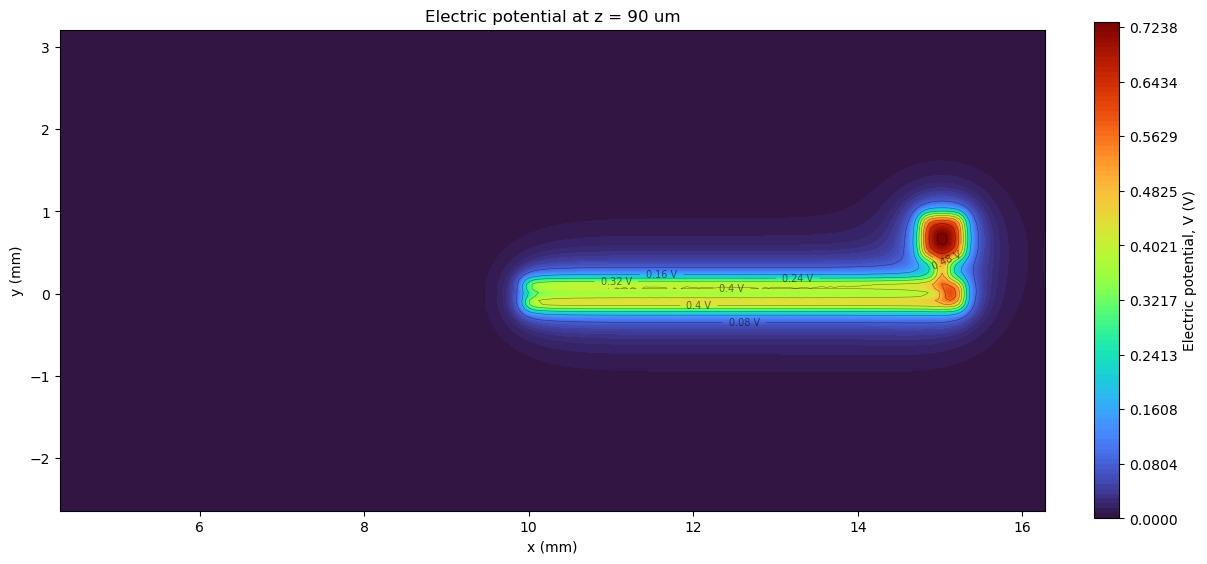

Potential range: 3.40304e-08 to 0.731096 V


In [15]:
# Plot electric potential on a horizontal plane above the chip.
# Run only after Study 1 has finished solving.

import numpy as np
import matplotlib.pyplot as plt
from jpype.types import JArray, JDouble

PLOT_Z_UM = 90.0       # Height above the metal center plane
NX = 240               # Reduced preview resolution
NY = 120
BATCH_POINTS = 2000    # Short COMSOL calls; interruptible between batches
DATASET_TAG = 'dset1'  # Stationary solution created by Study 1

dataset_tags = [str(tag) for tag in j.result().dataset().tags()]
print('Available result datasets:', dataset_tags)
if DATASET_TAG not in dataset_tags:
    raise RuntimeError(
        f'Dataset {DATASET_TAG!r} is unavailable. Wait for Study 1 to finish. '
        f'Available datasets: {dataset_tags}'
    )

# Use the chip footprint calculated earlier in the notebook.
x_um = np.linspace(chip_xmin, chip_xmax, NX)
y_um = np.linspace(chip_ymin, chip_ymax, NY)
X_um, Y_um = np.meshgrid(x_um, y_um)
x_flat = X_um.ravel()
y_flat = Y_um.ravel()

# Remove an older temporary interpolation node if this cell is rerun.
numerical_tags = [str(tag) for tag in j.result().numerical().tags()]
if "interp_potential" in numerical_tags:
    j.result().numerical().remove("interp_potential")

j.result().numerical().create("interp_potential", "Interp")
interp = j.result().numerical("interp_potential")
interp.label(f"Potential at z = {PLOT_Z_UM:g} um")
interp.set('data', DATASET_TAG)
interp.set("expr", ["V"])
interp.set("unit", ["V"])
interp.set("coorderr", "on")

# Evaluate in small batches. COMSOL API calls are synchronous, but each call
# remains short and the cell can be interrupted between calls. Coordinates
# are in the geometry unit (um), not meters.
point_count = x_flat.size
V_flat = np.full(point_count, np.nan, dtype=float)
for start in range(0, point_count, BATCH_POINTS):
    stop = min(start + BATCH_POINTS, point_count)
    coordinates = np.vstack([
        x_flat[start:stop],
        y_flat[start:stop],
        np.full(stop-start, PLOT_Z_UM),
    ])
    interp.setInterpolationCoordinates(
        JArray(JDouble, 2)(coordinates.tolist())
    )
    interp.run()
    raw = np.asarray(interp.getData(0), dtype=float)
    if raw.size == 0:
        raise RuntimeError(
            'The selected dataset has no solution data. Wait for the solve to '
            'finish. If Desktop solved a separate copy, save and load that MPH '
            'file into this MPh session.'
        )
    values = raw if raw.ndim == 1 else raw[-1, :]
    values = np.asarray(values, dtype=float).reshape(-1)
    if values.size != stop-start:
        raise RuntimeError(
            f'COMSOL returned {values.size} values for batch {start}:{stop}.'
        )
    V_flat[start:stop] = values
    print(f'Interpolated {stop:,}/{point_count:,} points', flush=True)

V = V_flat.reshape(Y_um.shape)

# Points outside the solution domain may be returned as NaN.
V_masked = np.ma.masked_invalid(V)
if V_masked.count() == 0:
    raise RuntimeError('All interpolated values are invalid at z = 90 um.')

fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)

levels = np.linspace(
    float(V_masked.min()),
    float(V_masked.max()),
    101,
)

contour = ax.contourf(
    X_um / 1000,       # Display millimeters
    Y_um / 1000,
    V_masked,
    levels=levels,
    cmap="turbo",
)

# Optional equipotential contours.
lines = ax.contour(
    X_um / 1000,
    Y_um / 1000,
    V_masked,
    levels=10,
    colors="black",
    linewidths=0.35,
    alpha=0.55,
)
ax.clabel(lines, inline=True, fontsize=7, fmt="%.3g V")

colorbar = fig.colorbar(contour, ax=ax)
colorbar.set_label("Electric potential, V (V)")

ax.set(
    title=f"Electric potential at z = {PLOT_Z_UM:g} µm",
    xlabel="x (mm)",
    ylabel="y (mm)",
)
ax.set_aspect("equal")
ax.set_title(f"Electric potential at z = {PLOT_Z_UM:g} um")

plt.show()

print(f"Potential range: {V_masked.min():.6g} to {V_masked.max():.6g} V")

Interpolated 2,000/38,400 YZ points
Interpolated 4,000/38,400 YZ points
Interpolated 6,000/38,400 YZ points
Interpolated 8,000/38,400 YZ points
Interpolated 10,000/38,400 YZ points
Interpolated 12,000/38,400 YZ points
Interpolated 14,000/38,400 YZ points
Interpolated 16,000/38,400 YZ points
Interpolated 18,000/38,400 YZ points
Interpolated 20,000/38,400 YZ points
Interpolated 22,000/38,400 YZ points
Interpolated 24,000/38,400 YZ points
Interpolated 26,000/38,400 YZ points
Interpolated 28,000/38,400 YZ points
Interpolated 30,000/38,400 YZ points
Interpolated 32,000/38,400 YZ points
Interpolated 34,000/38,400 YZ points
Interpolated 36,000/38,400 YZ points
Interpolated 38,000/38,400 YZ points
Interpolated 38,400/38,400 YZ points


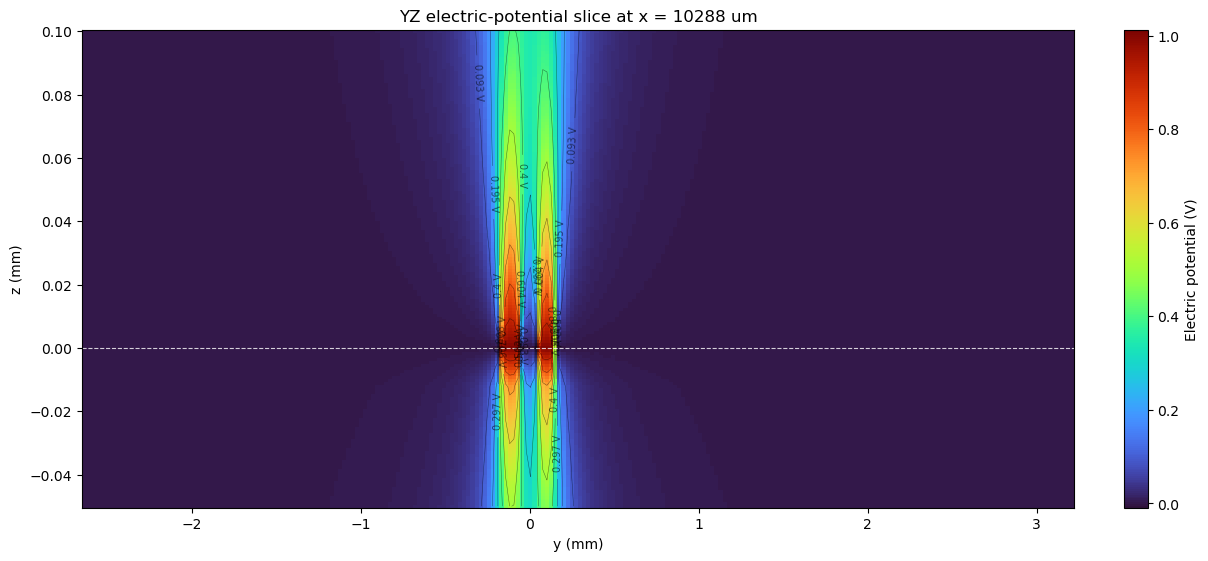

YZ potential range: -0.0092594361 to 1.01293537 V


In [17]:
# YZ potential slice at a fixed x coordinate.
# Run the solved-model loading cell first.
import numpy as np
import matplotlib.pyplot as plt
from jpype.types import JArray, JDouble

X_SLICE_UM = 0.5 * (chip_xmin + chip_xmax)  # Edit to move the YZ plane
YZ_Z_MIN_UM = -50.0                         # Vertical plot window
YZ_Z_MAX_UM = 100.0
YZ_NY = 240
YZ_NZ = 160
YZ_BATCH_POINTS = 2000
YZ_DATASET_TAG = 'dset1'

dataset_tags = [str(tag) for tag in j.result().dataset().tags()]
if YZ_DATASET_TAG not in dataset_tags:
    raise RuntimeError(
        'Load COMSOL_MODEL_V3_capacitance_setup_res.mph with the previous '
        'cell before plotting.'
    )

y_um = np.linspace(chip_ymin, chip_ymax, YZ_NY)
z_um = np.linspace(YZ_Z_MIN_UM, YZ_Z_MAX_UM, YZ_NZ)
Y_um, Z_um = np.meshgrid(y_um, z_um)
y_flat = Y_um.ravel()
z_flat = Z_um.ravel()

YZ_INTERP_TAG = 'interp_potential_yz'
numerical_tags = [str(tag) for tag in j.result().numerical().tags()]
if YZ_INTERP_TAG in numerical_tags:
    j.result().numerical().remove(YZ_INTERP_TAG)

j.result().numerical().create(YZ_INTERP_TAG, 'Interp')
yz_interp = j.result().numerical(YZ_INTERP_TAG)
yz_interp.label(f'YZ potential at x = {X_SLICE_UM:g} um')
yz_interp.set('data', YZ_DATASET_TAG)
yz_interp.set('expr', ['V'])
yz_interp.set('unit', ['V'])
# Some grid points can lie in ideal-conductor domains, where V is not a
# solved domain field. Keep those points as NaN instead of aborting.
yz_interp.set('coorderr', 'off')

point_count = y_flat.size
V_yz_flat = np.full(point_count, np.nan, dtype=float)
for start in range(0, point_count, YZ_BATCH_POINTS):
    stop = min(start + YZ_BATCH_POINTS, point_count)
    coordinates = np.vstack([
        np.full(stop-start, X_SLICE_UM),
        y_flat[start:stop],
        z_flat[start:stop],
    ])
    yz_interp.setInterpolationCoordinates(
        JArray(JDouble, 2)(coordinates.tolist())
    )
    yz_interp.run()
    raw = np.asarray(yz_interp.getData(0), dtype=float)
    if raw.size == 0:
        raise RuntimeError('The selected COMSOL dataset contains no data.')
    values = raw if raw.ndim == 1 else raw[-1, :]
    values = np.asarray(values, dtype=float).reshape(-1)
    if values.size != stop-start:
        raise RuntimeError(
            f'COMSOL returned {values.size} values for batch {start}:{stop}.'
        )
    V_yz_flat[start:stop] = values
    print(f'Interpolated {stop:,}/{point_count:,} YZ points', flush=True)

V_yz = np.ma.masked_invalid(V_yz_flat.reshape(Z_um.shape))
if V_yz.count() == 0:
    raise RuntimeError('Every point on the requested YZ plane is invalid.')

fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)
colored = ax.pcolormesh(
    Y_um / 1000.0, Z_um / 1000.0, V_yz,
    shading='auto', cmap='turbo',
)
vmin = float(V_yz.min())
vmax = float(V_yz.max())
if vmax > vmin:
    lines = ax.contour(
        Y_um / 1000.0, Z_um / 1000.0, V_yz,
        levels=np.linspace(vmin, vmax, 11), colors='black',
        linewidths=0.35, alpha=0.55,
    )
    ax.clabel(lines, inline=True, fontsize=7, fmt='%.3g V')

colorbar = fig.colorbar(colored, ax=ax)
colorbar.set_label('Electric potential (V)')
ax.axhline(0.0, color='white', linewidth=0.8, linestyle='--', alpha=0.8)
ax.set(
    title=f'YZ electric-potential slice at x = {X_SLICE_UM:g} um',
    xlabel='y (mm)', ylabel='z (mm)',
)
plt.show()

print(f'YZ potential range: {vmin:.9g} to {vmax:.9g} V')
